In [1113]:
from pychrtrace import ImageHandler, Tracer, SpotPicker, NucDetector
from pychrtrace import image_processing_functions as ip
from pychrtrace.gaussfit import fitSymmetricGaussian3D as fit_3D
import dask.array as da
import dask
import napari
import numpy as np
import scipy.ndimage as ndi
import pandas as pd

In [1114]:
path = r'Q:\ChromatinTeam\img_processing_t4\2021-02-02_Exp348_KSB_Elyra_WF_FISH_intensity_comp_rep\Ibidi_3_86deg\3C'
nuc_ch = 2
spot_ch = 0
ds=1
thresh=20000

In [1115]:
imgs, pos = ip.images_to_dask(path, ['.czi', 'DE_1'])
n = len(pos)

Loading files to dask array: 
[=========] 100.0%
 Loaded images of shape:  (10, 1, 3, 30, 1280, 1280)
Found positions  ['W0001', 'W0002', 'W0003', 'W0004', 'W0005', 'W0006', 'W0007', 'W0008', 'W0009', 'W0010']


In [1116]:
nucs = [da.max(imgs[pos,0,nuc_ch,::ds,::ds,::ds], axis=0).compute() for pos in range(imgs.shape[0])]
nuc_masks = ip.nuc_segmentation(nucs)
nucs = np.stack(nucs)
nuc_masks = [ndi.morphology.grey_dilation(img, 5) for img in nuc_masks]
nuc_masks = np.stack(nuc_masks)

>>>> using CPU
Running test snippet to check if MKL-DNN working
see https://pytorch.org/docs/stable/backends.html?highlight=mkl
** MKL version working - CPU version is sped up. **
processing 10 image(s)
100%|██████████| 10/10 [00:04<00:00,  2.03it/s]
time spent: running network 2.08s; flow+mask computation 2.71
estimated masks for 10 image(s) in 5.45 sec
>>>> TOTAL TIME 5.45 sec


In [1117]:
spot_imgs = np.vstack([da.max(imgs[pos,:,spot_ch,::ds,::ds,::ds], axis=1).compute() for pos in range(n)])

In [1118]:
labels = [np.unique(nuc_masks[i]) for i in range(n)]
nuc_int = []
for i in range(n):
    for l in labels[i]:
        mask = nuc_masks[i] == l
        nuc_int.append(np.median(spot_imgs[i][mask]))
print(np.median(nuc_int))

200.0


In [1119]:
spots, spot_segs = zip(*[ip.detect_spots(spot_imgs[i], thresh) for i in range(n)])
spots = [pos[['zc', 'yc']].to_numpy() for pos in spots]
spot_segs = np.stack(spot_segs)
points = np.vstack([np.insert(spots[i], 0, [i]*spots[i].shape[0], axis=1) for i in range(n)])
in_nuc = np.array([nuc_masks[tuple(points[i].astype(int))] != 0 for i in range(points.shape[0])])
points = points[in_nuc,:]

Found 60 spots.
Found 79 spots.
Found 60 spots.
Found 75 spots.
Found 98 spots.
Found 73 spots.
Found 88 spots.
Found 76 spots.
Found 94 spots.
Found 66 spots.


In [1120]:
with napari.gui_qt():
    viewer = napari.view_image(spot_imgs)
    viewer.add_image(spot_segs)
    viewer.add_image(nucs)
    viewer.add_labels(nuc_masks)
    new_points = viewer.add_points(points, size=12,
                            edge_width=3,
                            edge_color='red',
                            face_color='transparent',)
points = new_points.data

In [1121]:
points = np.round(points, decimals=0).astype(int)
zc = []
for i in range(points.shape[0]):
    zc.append(np.argmax(imgs[points[i,0], 0, spot_ch, :, points[i,1], points[i,2]]))
zc = dask.compute(zc)[0]
points = np.insert(points, 1, zc, axis=1)

In [1122]:
with napari.gui_qt():
    viewer = napari.view_image(imgs[:,0,nuc_ch], colormap='blue', blending='additive')
    viewer.add_image(imgs[:,0,spot_ch], blending='additive')
    new_points = viewer.add_points(points,
                        edge_width=3,
                        edge_color='red',
                        face_color='transparent',
                        n_dimensional=True,
                        size=np.array([1, 20, 15, 15]))

In [1123]:
sspot_imgs = []
for i in range(points.shape[0]):
    zmin = points[i,1]-5
    zmax = points[i,1]+5
    ymin = points[i,2]-8
    ymax = points[i,2]+8
    xmin = points[i,3]-8
    xmax = points[i,3]+8
    sspot_imgs.append(imgs[points[i,0], 0, spot_ch, zmin:zmax, ymin:ymax, xmin:xmax])
sspot_imgs = dask.compute(sspot_imgs)[0]

In [1124]:
fits = []
for i, img in enumerate(sspot_imgs):
    try:
        res = fit_3D(img, 1)[0]
    except ValueError:
        res = [np.nan]*7
    fits.append(res)

Fitting problem! 5 Number of calls to function has reached maxfev = 500.


In [1125]:
fits = pd.DataFrame(fits, columns=['BG', 'A', 'zc_zoom', 'yc_zoom', 'xc_zoom', 'sigma_xy','sigma_z'])
fits['A_to_BG'] = fits['A']/fits['BG']
pos = pd.DataFrame(points, columns=['position', 'zc', 'yc', 'xc'])
fits = pd.concat([fits, pos], axis=1)
fits = fits[fits['BG']>0]
fits.to_csv(path+'_fits.csv')

<AxesSubplot:ylabel='A'>

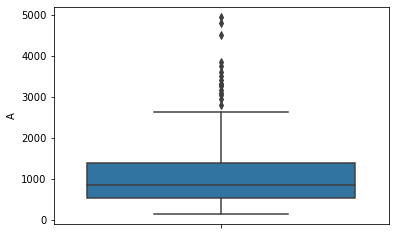

In [1126]:
import seaborn as sns 
sns.boxplot(data=fits.query('A<10000 & A>0'), y='A')